# Agentic Bug-Fixing Over Time: Adoption, Quality, and Durability

A short empirical study extending *"Understanding the Rejection of Fixes Generated by Agentic Pull Requests"* (MSR '26)
with a **temporal** view, using the [GitHub-Agentic-PR-Dataset](https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset).

**Data:** 422,618 bug-fix PRs (`type=fix`), Dec 2024 – Feb 2026 (15 months); 121,832 by agents
(Claude_Code, Cursor, Copilot, Devin), 300,786 by humans. **Rejected** = closed without merge; rates use closed PRs.

**Three questions:**
1. **Adoption** — which agent do people use to fix bugs, and how does it shift over time?
2. **Quality trend** — how does each agent's rejection rate evolve?
3. **Durability** — do merged agent fixes get reverted, vs human fixes?

*Scope notes (kept short):* this is the **full** dataset (no >100-star filter, so rejection is lower than the MSR paper's 46%);
the human group spans different repos, so treat it as a **rough reference**, not a matched control.

In [ ]:
import os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATA = r"C:\Users\Mahmoudabujadallah\final_agantic_bugfixes\data"
AGENTS = ["Claude_Code","Cursor","Copilot","Devin"]
COL = {"Claude_Code":"#9467bd","Cursor":"#2ca02c","Copilot":"#ff7f0e","Devin":"#8c564b"}

prs = pd.read_parquet(os.path.join(DATA,"fix_prs_only.parquet"),
        columns=["id","state","created_at","merged_at","is_agent","agent"])
prs["month"]   = prs["created_at"].str.slice(0,7)
prs            = prs[prs["month"].notna() & (prs["month"]!="")]
prs["closed"]  = prs["state"]=="closed"
_mna           = prs["merged_at"].isna() | prs["merged_at"].astype(str).isin(["","NaT","None"])
prs["rejected"]= prs["closed"] & _mna
prs["merged"]  = ~_mna
months = sorted(prs["month"].unique())
print(len(prs), "fix PRs |", months[0], "->", months[-1])

## RQ1 — Which agent fixes bugs, over time?

**People switch agents a lot.** Claude_Code + Cursor dominated early (~90% in Dec 2024).
**Copilot was ~2% until May 2025, then jumped to ~30%** (its coding-agent launch). **Devin faded** from a ~27% peak to ~5%.

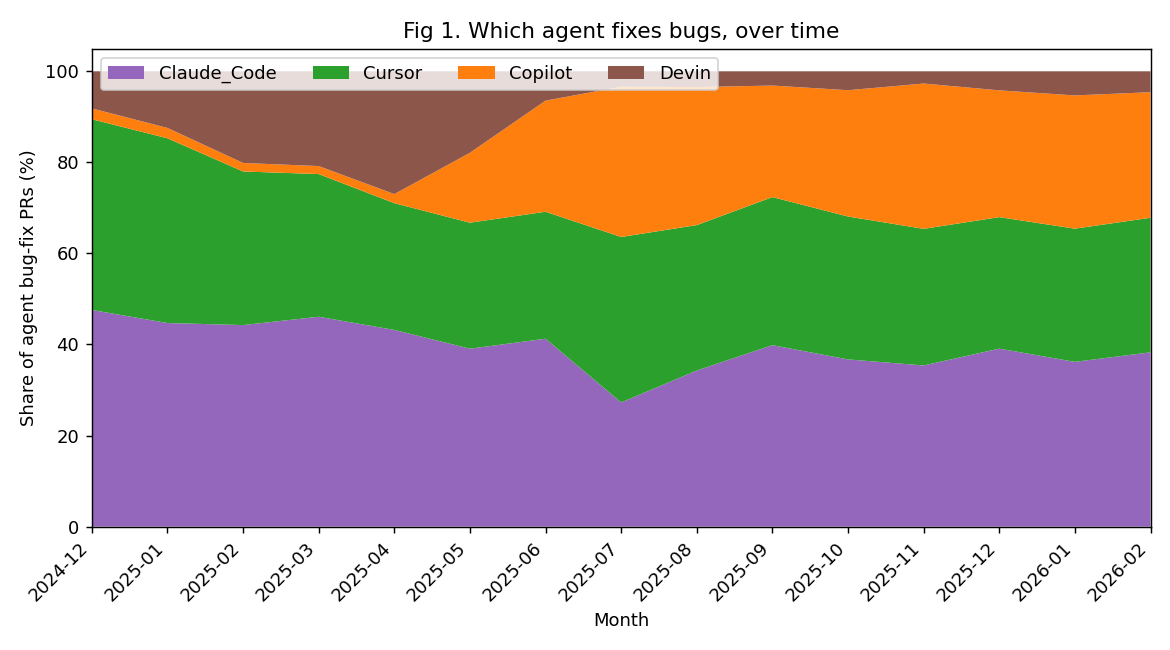

In [ ]:
agt = prs[prs.is_agent]
share = (agt[agt.agent.isin(AGENTS)].pivot_table(index="month", columns="agent",
         values="id", aggfunc="count", fill_value=0).reindex(months).fillna(0))
share = share.div(share.sum(axis=1), axis=0)*100
plt.figure(figsize=(9,5))
plt.stackplot(months, [share[a] for a in AGENTS], labels=AGENTS, colors=[COL[a] for a in AGENTS])
plt.ylabel("Share of agent bug-fix PRs (%)"); plt.xlabel("Month")
plt.title("Fig 1. Which agent fixes bugs, over time"); plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", ncol=4); plt.margins(x=0); plt.tight_layout(); plt.show()

## RQ2 — How does each agent's rejection rate evolve?

**The agents diverge — so we report them separately (an aggregate would hide this).**
**Claude_Code improves** (16.6% → 10.8%), while **Copilot worsens** (8.7% → 24.9%) and **Cursor rises** (5.5% → 12.5%);
**Devin** stays high (~30–40%). Trajectory, not a single "agent" trend, is the story.

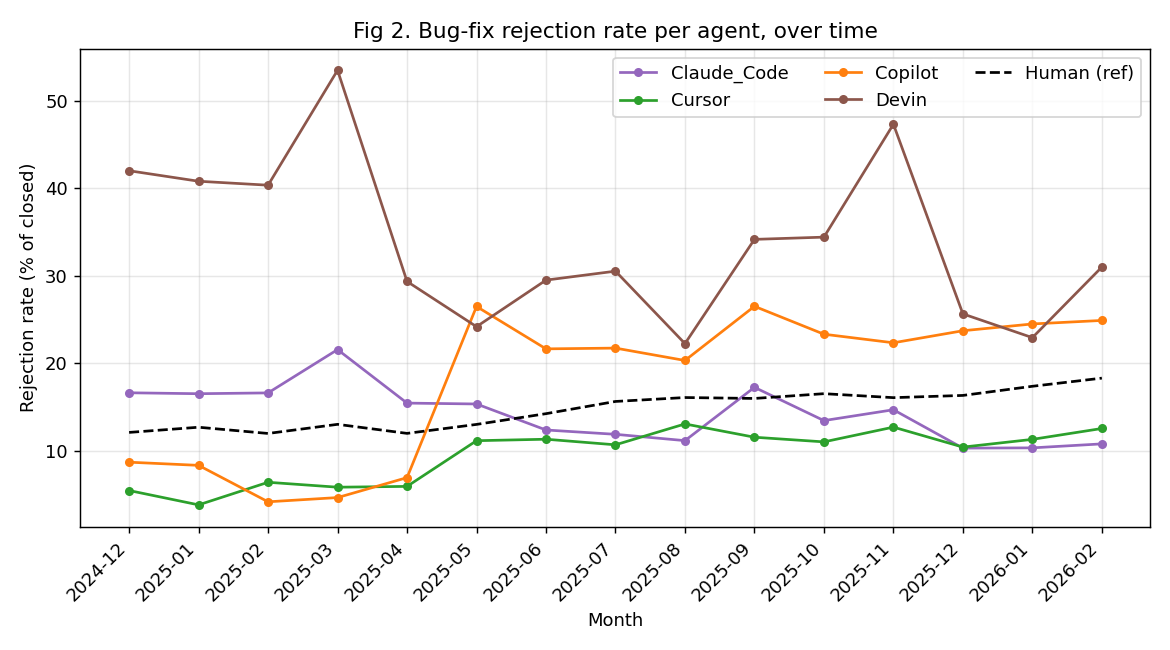

In [ ]:
from scipy.stats import spearmanr
def mrej(df):
    g = df[df.closed].groupby("month"); return (100*g["rejected"].mean()).reindex(months)
plt.figure(figsize=(9,5))
for a in AGENTS:
    r = mrej(prs[prs.agent==a]); plt.plot(months, r.values, "o-", color=COL[a], ms=4, label=a)
    rho,p = spearmanr(np.arange(len(r.dropna())), r.dropna().values)
    print(f"{a:12s} {r.dropna().iloc[0]:5.1f}% -> {r.dropna().iloc[-1]:5.1f}%  (rho={rho:+.2f}, p={p:.3f})")
plt.plot(months, mrej(prs[~prs.is_agent]).values, "k--", lw=1.5, label="Human (ref)")
plt.ylabel("Rejection rate (% of closed)"); plt.xlabel("Month")
plt.title("Fig 2. Bug-fix rejection rate per agent, over time"); plt.xticks(rotation=45, ha="right")
plt.legend(ncol=3); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ3 — Do merged bug-fixes get reverted?

We scan every PR commit message for `This reverts commit <sha>` and check if it targets a merged fix PR's commit.
**Agent fixes are reverted *less* than human fixes** (**0.05% vs 0.12%**), and this holds within a fixed merge-cohort
(exposure time is balanced, ~215 days each) — so it is **not** a survivorship effect. Reverts are rare overall: fixes are durable.
*Limit:* squash/rebase merges rewrite SHAs, so this is a lower bound.

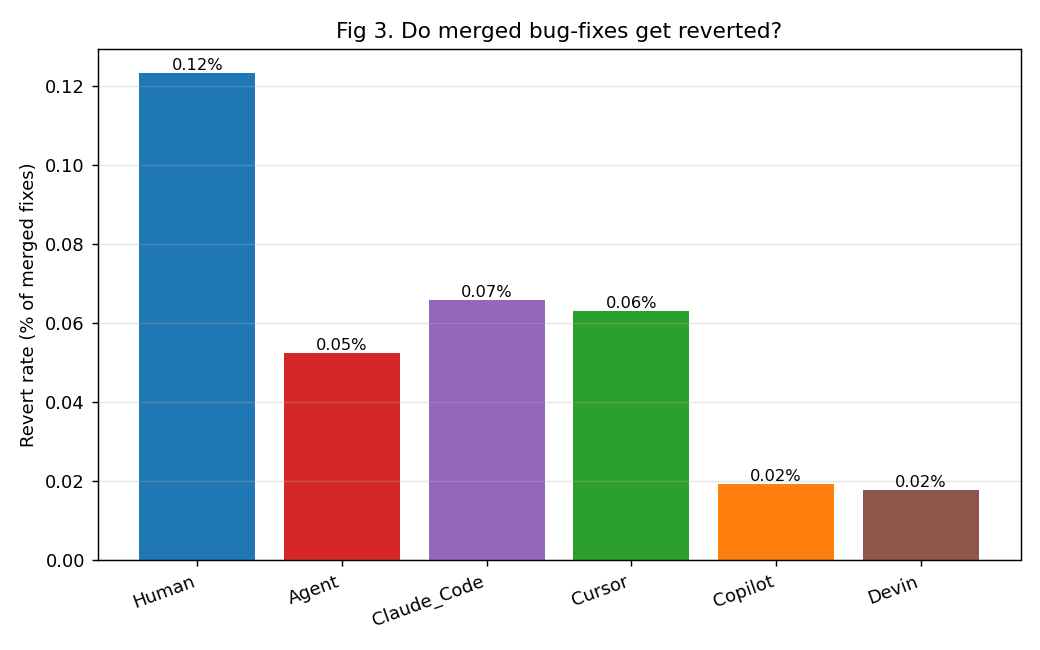

In [ ]:
com = pd.read_parquet(os.path.join(DATA,"pr_commits.parquet"), columns=["sha","pr_id","message"])
fixcom = com[com["pr_id"].isin(set(prs["id"]))]
sha_to_pr = dict(zip(fixcom["sha"].str.slice(0,12), fixcom["pr_id"]))
REV = re.compile(r"reverts commit ([0-9a-f]{7,40})", re.I)
rev_ids = set()
for pid,msg in zip(com["pr_id"], com["message"]):
    if not isinstance(msg,str) or "revert" not in msg.lower(): continue
    for ref in REV.findall(msg):
        o = sha_to_pr.get(ref[:12])
        if o is not None and o != pid: rev_ids.add(o)
m = prs[prs.merged].copy(); m["rev"] = m["id"].isin(rev_ids)
rr = lambda df: 100*df["rev"].mean()
print(f"Agent {rr(m[m.is_agent]):.3f}%  Human {rr(m[~m.is_agent]):.3f}%")
labels = ["Human","Agent"] + AGENTS
vals = [rr(m[~m.is_agent]), rr(m[m.is_agent])] + [rr(m[m.agent==a]) for a in AGENTS]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, vals, color=["#1f77b4","#d62728"]+[COL[a] for a in AGENTS])
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
plt.ylabel("Revert rate (% of merged fixes)"); plt.title("Fig 3. Do merged bug-fixes get reverted?")
plt.xticks(rotation=20, ha="right"); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## Take-aways

1. **Adoption churns fast** — the agent used for bug-fixing shifts month to month (Copilot's launch reshaped the mix).
2. **Agents are not interchangeable** — Claude_Code's fixes get *more* accepted over time while Copilot's get *less*;
   per-agent trajectories matter for anyone choosing or studying an agent.
3. **Agent fixes are durable** — once merged, they are reverted *less* than human fixes, and that is not a time artifact.

*Honest limits:* full-dataset scope (no star filter); human is an unmatched reference; revert counts are a lower bound.